# Train A Spectrogram CNN

This notebook converts each complex I/Q sample into a short-time Fourier representation and trains a 2D CNN for modulation classification.

Design choices:
- Use a complex STFT instead of a single full FFT so local time-frequency structure is preserved.
- Use a centered log-magnitude spectrogram so random carrier offsets become less destructive.
- Train a 2D CNN with mixed precision, cosine learning-rate decay, checkpointing, and early stopping.

In [1]:
from pathlib import Path
import math
import os
import platform
import subprocess
import time

import h5py
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as sc
import seaborn as sns
import torch
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch import nn
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid")
torch.manual_seed(0)
np.random.seed(0)

In [2]:
DATASET_PATH = Path("signals_dataset.h5")
CHECKPOINT_PATH = Path("spectrograph_cnn_signal_classifier.pt")

STFT_NPERSEG = 128
STFT_NOVERLAP = 96
STFT_NFFT = 128

BATCH_SIZE = 256
EPOCHS = 40
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
EARLY_STOPPING_PATIENCE = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_cuda = device.type == "cuda"
num_workers = min(8, os.cpu_count() or 1)
pin_memory = use_cuda
persistent_workers = num_workers > 0

if use_cuda:
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print(f"Python: {platform.python_version()}")
print(f"Torch: {torch.__version__}")
print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Workers: {num_workers}, pin_memory={pin_memory}")

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATASET_PATH.resolve()}")

Python: 3.12.3
Torch: 2.10.0+cu128
Device: cuda
CUDA available: True
Workers: 8, pin_memory=True


In [3]:
def query_nvidia_smi_text():
    cmd = [
        "nvidia-smi",
        "--query-gpu=index,name,driver_version,memory.total,memory.used,utilization.gpu,utilization.memory,temperature.gpu,power.draw",
        "--format=csv,noheader,nounits",
    ]
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, check=True)
        return result.stdout.strip()
    except Exception as exc:
        return f"nvidia-smi unavailable: {exc}"


def get_runtime_diagnostics():
    diagnostics = {
        "device": str(device),
        "cuda_available": bool(torch.cuda.is_available()),
        "cuda_device_count": int(torch.cuda.device_count()),
    }
    if use_cuda:
        diagnostics["gpu_name"] = torch.cuda.get_device_name(0)
        diagnostics["memory_allocated_mb"] = torch.cuda.memory_allocated() / 1024**2
        diagnostics["memory_reserved_mb"] = torch.cuda.memory_reserved() / 1024**2
        diagnostics["max_memory_allocated_mb"] = torch.cuda.max_memory_allocated() / 1024**2
        diagnostics["max_memory_reserved_mb"] = torch.cuda.max_memory_reserved() / 1024**2
    diagnostics["nvidia_smi"] = query_nvidia_smi_text()
    return diagnostics


def print_diagnostics(title: str, diagnostics: dict):
    print(title)
    for key, value in diagnostics.items():
        print(f"  {key}: {value}")


print_diagnostics("Initial diagnostics", get_runtime_diagnostics())

Initial diagnostics
  device: cuda
  cuda_available: True
  cuda_device_count: 1
  gpu_name: NVIDIA GeForce RTX 5090
  memory_allocated_mb: 0.0
  memory_reserved_mb: 0.0
  max_memory_allocated_mb: 0.0
  max_memory_reserved_mb: 0.0
  nvidia_smi: 0, NVIDIA GeForce RTX 5090, 590.48.01, 32607, 3486, 7, 6, 34, 46.78


In [4]:
with h5py.File(DATASET_PATH, "r") as h5_file:
    raw_signals = h5_file["signals"][:].astype(np.float32)
    labels = h5_file["labels"][:].astype(np.int64)
    class_names = [name.decode("utf-8") if isinstance(name, bytes) else str(name) for name in h5_file.attrs["class_names"]]

complex_signals = raw_signals[:, 0, :] + 1j * raw_signals[:, 1, :]
freqs, times, stft = sc.stft(
    complex_signals,
    fs=1.0,
    window="hann",
    nperseg=STFT_NPERSEG,
    noverlap=STFT_NOVERLAP,
    nfft=STFT_NFFT,
    return_onesided=False,
    boundary=None,
    padded=False,
    axis=-1,
)
stft = np.fft.fftshift(stft, axes=1)

magnitude = np.log1p(np.abs(stft))
mean_spectrum = magnitude.mean(axis=-1)
peak_bins = mean_spectrum.argmax(axis=1)
center_bin = magnitude.shape[1] // 2
for idx, peak_bin in enumerate(peak_bins):
    magnitude[idx] = np.roll(magnitude[idx], center_bin - peak_bin, axis=0)
features = magnitude[:, None, :, :].astype(np.float32)

print("spectrogram feature shape:", features.shape)
print("labels shape:", labels.shape)
print("classes:", class_names)
print("freq bins:", features.shape[2], "time frames:", features.shape[3])

unique_labels, counts = np.unique(labels, return_counts=True)
for idx, count in zip(unique_labels, counts):
    print(f"{class_names[idx]}: {count}")

spectrogram feature shape: (10000, 1, 128, 29)
labels shape: (10000,)
classes: ['16QAM', '64QAM', '8PSK', 'BPSK', 'PAM4', 'QPSK']
freq bins: 128 time frames: 29
16QAM: 1681
64QAM: 1660
8PSK: 1695
BPSK: 1601
PAM4: 1627
QPSK: 1736


In [5]:
def stratify_or_none(y: np.ndarray):
    _, counts = np.unique(y, return_counts=True)
    return y if np.all(counts >= 2) else None


X_train, X_temp, y_train, y_temp = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=0,
    stratify=stratify_or_none(labels),
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=0,
    stratify=stratify_or_none(y_temp),
)

channel_mean = X_train.mean(axis=(0, 2, 3), keepdims=True)
channel_std = X_train.std(axis=(0, 2, 3), keepdims=True) + 1e-6
X_train = (X_train - channel_mean) / channel_std
X_val = (X_val - channel_mean) / channel_std
X_test = (X_test - channel_mean) / channel_std

print("train:", X_train.shape, y_train.shape)
print("val:", X_val.shape, y_val.shape)
print("test:", X_test.shape, y_test.shape)
print("channel mean:", channel_mean.reshape(-1))
print("channel std:", channel_std.reshape(-1))

train: (8000, 1, 128, 29) (8000,)
val: (1000, 1, 128, 29) (1000,)
test: (1000, 1, 128, 29) (1000,)
channel mean: [0.06365276]
channel std: [0.07438569]


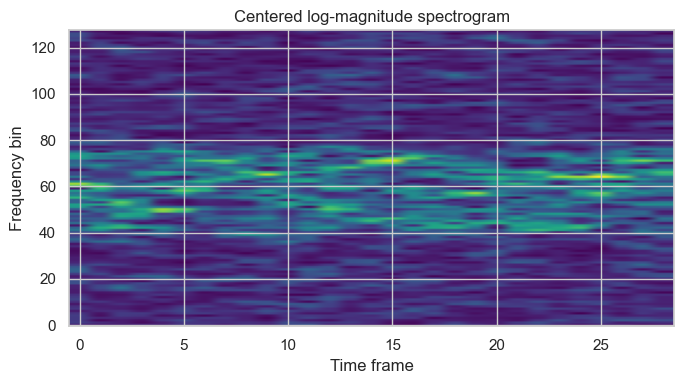

In [6]:
sample_idx = 0
fig, ax = plt.subplots(figsize=(7, 4))
ax.imshow(X_train[sample_idx, 0], aspect="auto", origin="lower", cmap="viridis")
ax.set_title("Centered log-magnitude spectrogram")
ax.set_xlabel("Time frame")
ax.set_ylabel("Frequency bin")
plt.tight_layout()

In [7]:
def make_loader(X: np.ndarray, y: np.ndarray, shuffle: bool) -> DataLoader:
    dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=persistent_workers,
    )


train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader = make_loader(X_val, y_val, shuffle=False)
test_loader = make_loader(X_test, y_test, shuffle=False)


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.pool(self.block(x))


class SpectrogramCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 192),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(192, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        return self.head(x)


model = SpectrogramCNN(num_classes=len(class_names)).to(device)
try:
    model = torch.compile(model)
    print("Compiled model with torch.compile")
except Exception as exc:
    print(f"torch.compile not used: {exc}")

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = GradScaler("cuda", enabled=use_cuda)
model

Compiled model with torch.compile


OptimizedModule(
  (_orig_mod): SpectrogramCNN(
    (features): Sequential(
      (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ConvBlock(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): GELU(approximate='none')
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): GELU(approximate='none')
        )
        (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (

In [8]:
def run_epoch(model: nn.Module, loader: DataLoader, training: bool):
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    start = time.perf_counter()

    for X_batch, y_batch in loader:
        if use_cuda:
            X_batch = X_batch.pin_memory().to(device, non_blocking=True)
            y_batch = y_batch.pin_memory().to(device, non_blocking=True)
        else:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

        with torch.set_grad_enabled(training):
            with autocast(device_type=device.type, enabled=use_cuda):
                logits = model(X_batch)
                loss = criterion(logits, y_batch)

            if training:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()

        total_loss += loss.item() * y_batch.size(0)
        total_correct += (logits.argmax(dim=1) == y_batch).sum().item()
        total_examples += y_batch.size(0)

    elapsed = time.perf_counter() - start
    samples_per_sec = total_examples / elapsed if elapsed > 0 else float("inf")
    return total_loss / total_examples, total_correct / total_examples, elapsed, samples_per_sec


history = {
    "train_loss": [],
    "train_acc": [],
    "train_time": [],
    "train_sps": [],
    "val_loss": [],
    "val_acc": [],
    "val_time": [],
    "val_sps": [],
    "learning_rate": [],
}
best_state = None
best_val_acc = -1.0
best_epoch = 0
epochs_without_improvement = 0
training_start = time.perf_counter()

if use_cuda:
    torch.cuda.reset_peak_memory_stats()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_time, train_sps = run_epoch(model, train_loader, training=True)
    val_loss, val_acc, val_time, val_sps = run_epoch(model, val_loader, training=False)
    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_time"].append(train_time)
    history["train_sps"].append(train_sps)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_time"].append(val_time)
    history["val_sps"].append(val_sps)
    history["learning_rate"].append(current_lr)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        epochs_without_improvement = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        torch.save(
            {
                "model_state_dict": best_state,
                "class_names": class_names,
                "feature_shape": tuple(features.shape[1:]),
                "channel_mean": channel_mean.astype(np.float32),
                "channel_std": channel_std.astype(np.float32),
                "stft_nperseg": STFT_NPERSEG,
                "stft_noverlap": STFT_NOVERLAP,
                "stft_nfft": STFT_NFFT,
                "epoch": epoch,
                "val_accuracy": val_acc,
            },
            CHECKPOINT_PATH,
        )
    else:
        epochs_without_improvement += 1

    diagnostics = get_runtime_diagnostics()
    diagnostics["epoch"] = epoch
    diagnostics["train_samples_per_sec"] = train_sps
    diagnostics["val_samples_per_sec"] = val_sps
    diagnostics["learning_rate"] = current_lr

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {train_loss:.4f} acc {train_acc:.3f} time {train_time:.2f}s {train_sps:.1f} samp/s | "
        f"val loss {val_loss:.4f} acc {val_acc:.3f} time {val_time:.2f}s {val_sps:.1f} samp/s | "
        f"lr {current_lr:.2e}"
    )
    print_diagnostics(f"Epoch {epoch:02d} diagnostics", diagnostics)

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping after {epoch} epochs")
        break

if best_state is not None:
    model.load_state_dict(best_state)

total_training_time = time.perf_counter() - training_start
print(f"Saved best checkpoint to: {CHECKPOINT_PATH.resolve()}")
print(f"Best epoch: {best_epoch}")
print(f"Best validation accuracy: {best_val_acc:.3f}")
print(f"Total training time: {total_training_time:.2f}s")

Epoch 01/40 | train loss 1.7985 acc 0.165 time 15.19s 526.7 samp/s | val loss 1.7931 acc 0.159 time 2.52s 396.2 samp/s | lr 3.00e-04
Epoch 01 diagnostics
  device: cuda
  cuda_available: True
  cuda_device_count: 1
  gpu_name: NVIDIA GeForce RTX 5090
  memory_allocated_mb: 30.35888671875
  memory_reserved_mb: 130.0
  max_memory_allocated_mb: 1031.26513671875
  max_memory_reserved_mb: 1082.0
  nvidia_smi: 0, NVIDIA GeForce RTX 5090, 590.48.01, 32607, 4277, 92, 83, 39, 252.51
  epoch: 1
  train_samples_per_sec: 526.741847978887
  val_samples_per_sec: 396.16389100660706
  learning_rate: 0.00029953760005996916
Epoch 02/40 | train loss 1.7937 acc 0.173 time 2.45s 3259.8 samp/s | val loss 1.7915 acc 0.161 time 0.02s 55440.9 samp/s | lr 2.98e-04
Epoch 02 diagnostics
  device: cuda
  cuda_available: True
  cuda_device_count: 1
  gpu_name: NVIDIA GeForce RTX 5090
  memory_allocated_mb: 30.35888671875
  memory_reserved_mb: 756.0
  max_memory_allocated_mb: 1031.26513671875
  max_memory_reserved_m

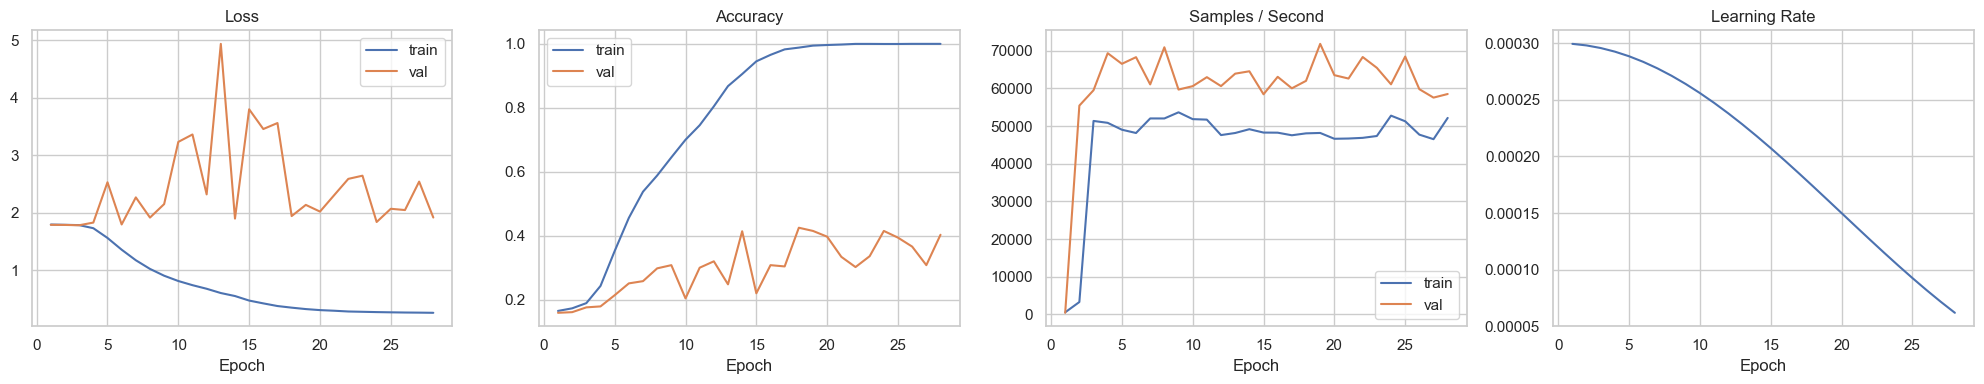

In [9]:
epochs = np.arange(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="train")
axes[1].plot(epochs, history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(epochs, history["train_sps"], label="train")
axes[2].plot(epochs, history["val_sps"], label="val")
axes[2].set_title("Samples / Second")
axes[2].set_xlabel("Epoch")
axes[2].legend()

axes[3].plot(epochs, history["learning_rate"])
axes[3].set_title("Learning Rate")
axes[3].set_xlabel("Epoch")

plt.tight_layout()

Test accuracy: 0.420
Test throughput: 6592.0 samples/s
              precision    recall  f1-score   support

       16QAM       0.33      0.32      0.32       168
       64QAM       0.39      0.45      0.42       166
        8PSK       0.34      0.34      0.34       170
        BPSK       0.66      0.63      0.65       160
        PAM4       0.45      0.64      0.53       163
        QPSK       0.30      0.18      0.23       173

    accuracy                           0.42      1000
   macro avg       0.41      0.42      0.41      1000
weighted avg       0.41      0.42      0.41      1000



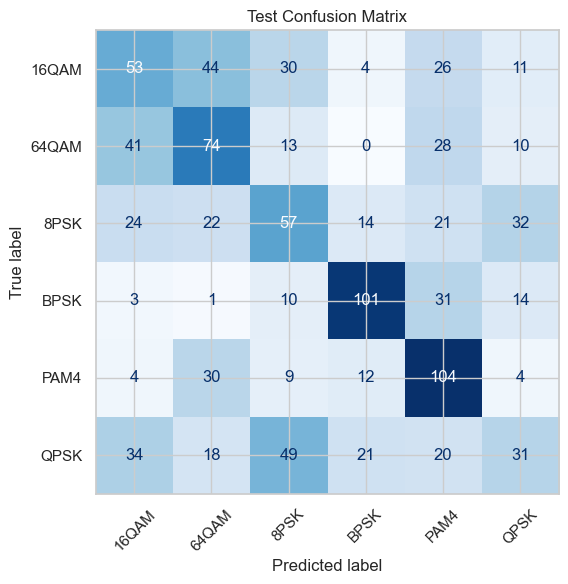

In [10]:
model.eval()
all_preds = []
all_targets = []
test_start = time.perf_counter()

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        if use_cuda:
            X_batch = X_batch.pin_memory().to(device, non_blocking=True)
            y_batch = y_batch.pin_memory().to(device, non_blocking=True)
        else:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

        with autocast(device_type=device.type, enabled=use_cuda):
            logits = model(X_batch)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(y_batch.cpu().numpy())

test_elapsed = time.perf_counter() - test_start
y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_targets)
test_acc = (y_pred == y_true).mean()

print(f"Test accuracy: {test_acc:.3f}")
print(f"Test throughput: {len(y_true) / test_elapsed:.1f} samples/s")
print(classification_report(y_true, y_pred, target_names=class_names, labels=np.arange(len(class_names)), zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
ax.set_title("Test Confusion Matrix")
plt.tight_layout()

## Notes

If this notebook underperforms the time-domain CNN, the usual reasons are:
- the dataset is more separable in local waveform structure than in spectrogram structure
- even after centering, carrier offset and symbol-rate variation still distort the spectrogram
- spectrogram magnitude is more robust than raw FFT phase, but it still discards some class information that raw I/Q preserves

Promising follow-up experiments:
- add random frequency-shift augmentation in the spectrogram domain
- try a larger STFT window such as `nperseg=256`
- use a hybrid model that processes raw I/Q and spectrograms in parallel
- explicitly estimate and remove carrier offset before the STFT